In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../data/processed/cleaned_supply_chain_no_fraud.csv')

In [3]:
df.columns.to_list()

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Id',
 'Customer Segment',
 'Customer State',
 'Customer Zipcode',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Product Card Id',
 'Product Name',
 'Product Price',
 'Product Status',
 'shipping date (DateOrders)',
 'Shipping Mode']

In [4]:
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])

In [37]:
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])

In [6]:
df.dtypes[['shipping date (DateOrders)','order date (DateOrders)']]

shipping date (DateOrders)    datetime64[ns]
order date (DateOrders)       datetime64[ns]
dtype: object

In [7]:
df[['Days for shipment (scheduled)', 'Order Item Quantity', 'Sales per customer', 'Late_delivery_risk']].corr()['Late_delivery_risk']

Days for shipment (scheduled)   -0.379429
Order Item Quantity             -0.000279
Sales per customer              -0.004014
Late_delivery_risk               1.000000
Name: Late_delivery_risk, dtype: float64

In [8]:
numeric_cols = ['Days for shipment (scheduled)', 'Order Item Quantity', 'Sales per customer', 'Late_delivery_risk']
df[numeric_cols].corr()

,Days for shipment (scheduled),Order Item Quantity,Sales per customer,Late_delivery_risk
Days for shipment (scheduled),1.000000,-0.002686,0.006892,-0.379429
Order Item Quantity,-0.002686,1.000000,0.105752,-0.000279
Sales per customer,0.006892,0.105752,1.000000,-0.004014
Late_delivery_risk,-0.379429,-0.000279,-0.004014,1.000000


<Axes: >

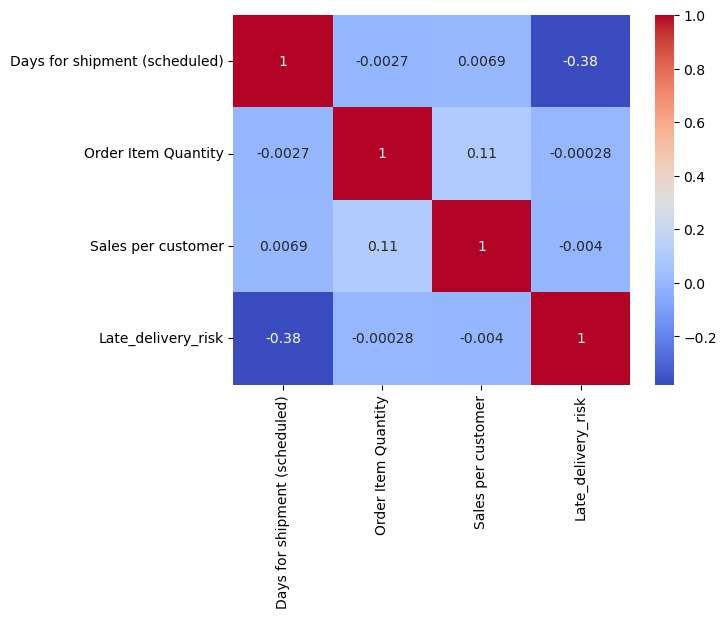

In [9]:
import seaborn as sns
sns.heatmap(df[numeric_cols].corr(), annot = True, cmap='coolwarm')

In [10]:
from scipy.stats import chi2_contingency

contingency_table_shipping = pd.crosstab(df['Shipping Mode'], df['Late_delivery_risk'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table_shipping)

print(contingency_table_shipping)
print(f"Chi2 statistic: {chi2:.2f}")
print(f"P-value: {p_value:.4f}")

Late_delivery_risk      0      1
Shipping Mode                   
First Class           615  26512
Same Day             5064   4454
Second Class         7480  26987
Standard Class      64319  41023
Chi2 statistic: 38912.32
P-value: 0.0000


In [11]:
contingency_table_market = pd.crosstab(df['Market'], df['Late_delivery_risk'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table_market)

print(f"Chi2 statistic: {chi2:.2f}")
print(f"P-value: {p_value:.4f}")

Chi2 statistic: 9.08
P-value: 0.0592


In [12]:
contingency_table_customer = pd.crosstab(df['Customer Segment'], df['Late_delivery_risk'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table_customer)

print(f"Chi2 statistic: {chi2:2f}")
print(f"P-value: {p_value:.4f}")

Chi2 statistic: 1.740708
P-value: 0.4188


In [13]:
contingency_table_category = pd.crosstab(df['Category Name'], df['Late_delivery_risk'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table_category)

print(f"Chi2 statistic: {chi2:2f}")
print(f"P-value: {p_value:.4f}")

Chi2 statistic: 44.333365
P-value: 0.6625


In [14]:
contingency_table_geo = pd.crosstab(df['Market'], df['Order Region'])
contingency_table_geo

Order Region,Canada,Caribbean,Central Africa,Central America,Central Asia,East Africa,East of USA,Eastern Asia,Eastern Europe,North Africa,...,South Asia,South of USA,Southeast Asia,Southern Africa,Southern Europe,US Center,West Africa,West Asia,West of USA,Western Europe
Market,,,,,,,,,,,,,,,,,,,,,
Africa,0,0,1649,0,0,1821,0,0,0,3157,...,0,0,0,1125,0,0,3625,0,0,0
Europe,0,0,0,0,0,0,0,0,3846,0,...,0,0,0,0,9208,0,0,0,0,26403
LATAM,0,8128,0,27710,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Pacific Asia,0,0,0,0,547,0,0,7124,0,0,...,7587,0,9351,0,0,0,0,5862,0,0
USCA,930,0,0,0,0,0,6765,0,0,0,...,0,3979,0,0,0,5766,0,0,7757,0


In [15]:
contingency_table_region = pd.crosstab(df['Order Region'], df['Late_delivery_risk'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table_region)

print(f"Chi2 statistic: {chi2:.2f}")
print(f"P-value: {p_value:.4f}")

Chi2 statistic: 74.39
P-value: 0.0000


In [16]:
#check the actual size of the effect
df.groupby('Order Region')['Late_delivery_risk'].mean().sort_values(ascending = False)

Order Region
Central Africa     0.589448
Western Europe     0.573382
South Asia         0.573349
East of USA        0.568958
East Africa        0.568918
Eastern Europe     0.567343
South of  USA      0.566977
West Asia          0.566701
Southeast Asia     0.566463
US Center          0.563996
Central America    0.560014
Central Asia       0.559415
North Africa       0.558125
Southern Europe    0.557016
South America      0.556539
West of USA        0.556014
Eastern Asia       0.555166
Oceania            0.552677
Northern Europe    0.550047
Southern Africa    0.548444
Caribbean          0.543184
West Africa        0.538759
Canada             0.503226
Name: Late_delivery_risk, dtype: float64

Given Shipping Mode already captures the dominant late-delivery pattern, and Order Region's effect is real but comparatively small (8.6-point spread vs. 57-point spread), Order Region will be excluded from the initial model to keep it focused on the strongest signal - worth revisiting if model performance suggests missing signal later.

In [17]:
df.groupby('Shipping Mode')['Days for shipment (scheduled)'].nunique()

Shipping Mode
First Class       1
Same Day          1
Second Class      1
Standard Class    1
Name: Days for shipment (scheduled), dtype: int64

In [18]:
already_tested = ['Shipping Mode', 'Market', 'Customer Segment', 'Category Name', 'Order Region', 'Days for shipment (scheduled)', 'Order Item Quantity', 'Sales per customer']
not_usable = ['Late_delivery_risk', 'Order Id', 'Order Item Id', 'Order Customer Id',
              'Customer Id', 'Customer Zipcode', 'order date (DateOrders)', 
              'shipping date (DateOrders)', 'Order City', 'order_month', 'after_drop',
              'Latitude', 'Longitude', 'Product Card Id']
remaining_cols = [col for col in df.columns if col not in already_tested and col not in not_usable]
remaining_cols

['Type',
 'Days for shipping (real)',
 'Benefit per order',
 'Delivery Status',
 'Customer City',
 'Customer Country',
 'Customer State',
 'Department Name',
 'Order Country',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order State',
 'Order Status',
 'Product Name',
 'Product Price',
 'Product Status']

In [19]:
df.dtypes[remaining_cols]

Type                         object
Days for shipping (real)      int64
Benefit per order           float64
Delivery Status              object
Customer City                object
Customer Country             object
Customer State               object
Department Name              object
Order Country                object
Order Item Discount         float64
Order Item Discount Rate    float64
Order Item Product Price    float64
Order Item Profit Ratio     float64
Sales                       float64
Order Item Total            float64
Order Profit Per Order      float64
Order State                  object
Order Status                 object
Product Name                 object
Product Price               float64
Product Status                int64
dtype: object

In [20]:
for col in remaining_cols:
    if pd.api.types.is_numeric_dtype(df[col]):
        corr = df[[col, 'Late_delivery_risk']].corr().iloc[0,1]
        print(f"{col}: correlation = {corr:.4f}")
    else:
        contingency_table_remain = pd.crosstab(df[col], df['Late_delivery_risk'])
        chi2, p_value, dof, expected = chi2_contingency(contingency_table_remain)
        print(f"{col}: p-value = {p_value:.4f}")
    

Type: p-value = 0.0000
Days for shipping (real): correlation = 0.4117
Benefit per order: correlation = -0.0041
Delivery Status: p-value = 0.0000
Customer City: p-value = 0.0000
Customer Country: p-value = 0.9766
Customer State: p-value = 0.0000
Department Name: p-value = 0.6935
Order Country: p-value = 0.0000
Order Item Discount: correlation = -0.0006
Order Item Discount Rate: correlation = 0.0008
Order Item Product Price: correlation = -0.0022
Order Item Profit Ratio: correlation = -0.0028
Sales: correlation = -0.0037
Order Item Total: correlation = -0.0040
Order Profit Per Order: correlation = -0.0041
Order State: p-value = 0.0000
Order Status: p-value = 0.0000
Product Name: p-value = 0.8015
Product Price: correlation = -0.0022
Product Status: correlation = nan


In [21]:
for col in ['Type', 'Product Name']:
    contingency_table = pd.crosstab(df[col], df['Late_delivery_risk'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print(f"{col}: chi2={chi2:.4f}, dof={dof}, p-value={p_value:.6f}")

Type: chi2=268.9561, dof=3, p-value=0.000000
Product Name: chi2=103.8929, dof=117, p-value=0.801525


In [22]:
pd.crosstab(df['Order Country'], df['Order State']).shape

(164, 1084)

In [23]:
df.groupby('Customer City')['Order Country'].nunique().describe()

count    562.000000
mean      27.770463
std       13.989772
min        5.000000
25%       19.250000
50%       25.000000
75%       33.000000
max      153.000000
Name: Order Country, dtype: float64

In [24]:
df.groupby('Order State')['Order Country'].nunique().describe()

count    1084.00000
mean        1.02583
std         0.24924
min         1.00000
25%         1.00000
50%         1.00000
75%         1.00000
max         7.00000
Name: Order Country, dtype: float64

In [25]:
df['Order State'].nunique()


1084

In [26]:
df['Customer City'].nunique()

562

Leakage: Days for shipping (real), Delivery Status
Fraud contamination: Order Status
Not significant: Customer Country, Department Name, Product Name, Market, Customer Segment, Category Name
Near-zero correlation: all discount/price/profit numeric columns
Redundant (multicollinearity): Days for shipment (scheduled) (= Shipping Mode), Order State (≈ Order Country)
High cardinality, weak signal: Order City, Customer City, Order State/geography broadly

In [27]:
df['Type'].nunique()

4

In [28]:
X = pd.get_dummies(df[['Shipping Mode', 'Type']], drop_first = True)
y = df['Late_delivery_risk']
X.head()

,Shipping Mode_Same Day,Shipping Mode_Second Class,Shipping Mode_Standard Class,Type_DEBIT,Type_PAYMENT,Type_TRANSFER
0,False,False,True,True,False,False
1,False,False,True,False,False,True
2,False,False,True,False,False,False
3,False,False,True,True,False,False
4,False,False,True,False,True,False


In [29]:
X = X.astype(int)
X.head()

,Shipping Mode_Same Day,Shipping Mode_Second Class,Shipping Mode_Standard Class,Type_DEBIT,Type_PAYMENT,Type_TRANSFER
0,0,0,1,1,0,0
1,0,0,1,0,0,1
2,0,0,1,0,0,0
3,0,0,1,1,0,0
4,0,0,1,0,1,0


Type (payment method) was retained despite no obvious causal link to shipping lateness - it passed chi-square testing (p < 0.001), is known at order time, and isn't leakage or fraud-related. It may be capturing an indirect relationship (e.g., correlating with customer/regional patterns not otherwise in the model). Retained with this caveat rather than dropped on intuition alone.

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_train.shape, X_test.shape)

(141163, 6) (35291, 6)


In [31]:
import xgboost as xgb

model = xgb.XGBClassifier(random_state = 42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [32]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[13721  1685]
 [ 9026 10859]]
              precision    recall  f1-score   support

           0       0.60      0.89      0.72     15406
           1       0.87      0.55      0.67     19885

    accuracy                           0.70     35291
   macro avg       0.73      0.72      0.69     35291
weighted avg       0.75      0.70      0.69     35291



Model Performance and Business Cost Interpretation

The delivery risk model was evaluated using a confusion matrix, which breaks predictions into four outcomes: true positives (correctly flagged late orders), true negatives (correctly cleared orders), false positives (orders wrongly flagged as late), and false negatives (late orders the model missed entirely).

On the test set of 35,291 orders, the model produced the following results:

True Positives: 10,859
True Negatives: 13,721
False Positives: 1,685
False Negatives: 9,026

Two metrics matter more than overall accuracy here, and they answer different questions.

Recall asks: of all the orders that were actually late, how many did the model catch? Recall is calculated as True Positives divided by (True Positives plus False Negatives), which comes out to 10,859 divided by 19,885, or about 55 percent. This means the model correctly identifies just over half of all genuinely late orders, missing the other 45 percent entirely.

Precision asks a different question: of all the orders the model flagged as late, how many actually were? Precision is calculated as True Positives divided by (True Positives plus False Positives), which comes out to 10,859 divided by 12,544, or about 87 percent. When the model does raise a late delivery flag, it is right the large majority of the time.

Together, these two numbers describe a model that is conservative rather than aggressive. It rarely raises a false alarm, but it also stays silent on a large share of real problems. For an operations team relying on this model to decide which orders need intervention, that tradeoff has a direct cost.

The 9,026 false negatives represent late orders the model told the business were safe. No intervention would be triggered for these orders under the current model. Using the dataset's own measured profit gap between late and on time orders (approximately 0.78 dollars per order), these missed orders represent an estimated 7,040 dollars in direct margin impact on this test set alone. This is very likely an underestimate of the true cost, since the larger consequence of undetected lateness is probably customer retention and repeat purchase behavior, which this dataset cannot directly measure.

It is also worth noting that false negatives are not the only cost worth considering. The 1,685 false positives represent cases where operations effort might be spent addressing orders that were never actually at risk. A complete cost benefit analysis would weigh both types of error, not only the more costly seeming one, before deciding how aggressively the model's threshold should be tuned.

In [33]:
#reducing the threshold to target increase in recall but lower precision
y_proba = model.predict_proba(X_test)[:, 1]
y_pred_adjusted = (y_proba >= 0.35).astype(int)

print(confusion_matrix(y_test, y_pred_adjusted))
print(classification_report(y_test, y_pred_adjusted))

[[    0 15406]
 [    0 19885]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     15406
           1       0.56      1.00      0.72     19885

    accuracy                           0.56     35291
   macro avg       0.28      0.50      0.36     35291
weighted avg       0.32      0.56      0.41     35291



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


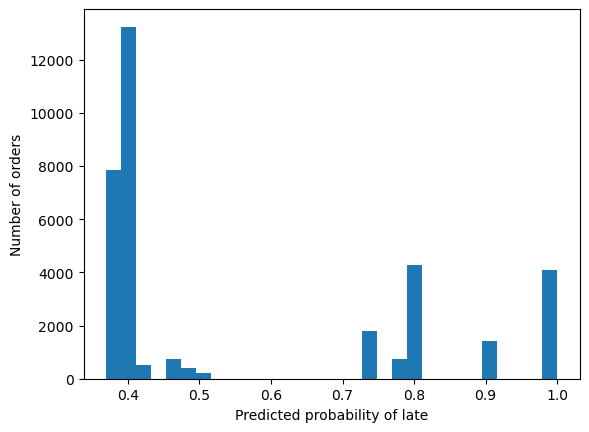

In [34]:
import matplotlib.pyplot as plt
plt.hist(y_proba, bins=30)
plt.xlabel('Predicted probability of late')
plt.ylabel('Number of orders')
plt.show()

after readjusting the baseline, the model collapse. I investigate the distribution of probability by graph and see that a huge chunk of probability clustering around 0.35 to 0.45, so if we set the baseline is 35%, the model just keep guessing "late" for all of them to achieve recall of 100%, but precision goes down to 0. This confirm that lowering the baseline is not a solution for this problem, we need to investigate the adding more features

In [38]:
#testing day of week
df['order_day_of_week'] =df['order date (DateOrders)'].dt.day_name()

contingency_table = pd.crosstab(df['order_day_of_week'], df['Late_delivery_risk'])
chi2, p_value,dof,expected = chi2_contingency(contingency_table)
print(f"P-value: {p_value:.4f}")

df.groupby('order_day_of_week')['Late_delivery_risk'].mean().sort_values(ascending = False)

P-value: 0.2206


order_day_of_week
Monday       0.565510
Friday       0.563376
Sunday       0.563103
Wednesday    0.561338
Thursday     0.560728
Saturday     0.557472
Tuesday      0.554855
Name: Late_delivery_risk, dtype: float64

In [41]:
group_stats = df.groupby(['Shipping Mode', 'Type'])['Late_delivery_risk'].agg(['mean', 'count'])
group_stats
lamda row: max(row['mean'], 1 - row['mean']) * row['count'], axis = 1

mean  count
Shipping Mode  Type                     
First Class    CASH      1.000000   3017
               DEBIT     1.000000  10761
               PAYMENT   1.000000   6222
               TRANSFER  0.913708   7127
Same Day       CASH      0.501779   1124
               DEBIT     0.477211   3686
               PAYMENT   0.477844   2189
               TRANSFER  0.430726   2519
Second Class   CASH      0.787329   3804
               DEBIT     0.795843  13470
               PAYMENT   0.806260   8403
               TRANSFER  0.739135   8790
Standard Class CASH      0.388399  11671
               DEBIT     0.396558  41376
               PAYMENT   0.399880  24910
               TRANSFER  0.369582  27385

In [44]:
group_stats = df.groupby(['Shipping Mode', 'Type'])['Late_delivery_risk'].agg(['mean', 'count']).reset_index()
group_stats['best_possible_correct'] = group_stats.apply(
    lambda row: max(row['mean'], 1 - row['mean']) * row['count'], axis = 1
)

ceiling_accuracy = group_stats['best_possible_correct'].sum() / group_stats['count'].sum()
print(f"Theoretical ceiling accuracy with current features: {ceiling_accuracy:.4f}")

Theoretical ceiling accuracy with current features: 0.6964
